In [2]:
from getdist import plots, MCSamples, loadMCSamples
import matplotlib   
import numpy as np
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 16


In [ ]:
bobe_samples = loadMCSamples('./results/CPL/Planck_DESI_CPL_Rotation_0_BOBE_Fisher') #loadMCSamples('./results/CPL/Planck_DESI_CPL_Rotation_42')
reference_samples = loadMCSamples(
            './cosmo_input/chains/union3_CPL',
            settings={'ignore_rows': 0.3, 'label': 'MCMC'})

param_names = bobe_samples.getParamNames().list()
param_indices = np.arange(len(param_names))
# Get full covariance matrix then extract subset in correct order
full_cov = reference_samples.getCov()
cov_matrix = full_cov[np.ix_(param_indices, param_indices)]
print(f"\nCovariance matrix shape: {cov_matrix.shape}")
# print(f"Covariance matrix:\n{cov_matrix}")

# Get best-fit point in correct order
best_fit = reference_samples.getBestFit(max_posterior=True)
center_point = np.array([best_fit.getParamDict()[name] for name in param_names])
print(f"\nBest-fit point (center): {center_point}")

gauss_samples = np.random.multivariate_normal(mean=center_point, cov=cov_matrix, size=10000)
gauss_samples = MCSamples(samples=gauss_samples, names=param_names, label='Gaussian')

./results/CPL/Planck_DESI_CPL_Rotation_0_BOBE_Fisher.txt
Removed no burn in

Covariance matrix shape: (17, 17)

Best-fit point (center): [-6.63976937e-01 -1.11464708e+00  1.19379181e-01  2.21962386e-02
  6.60022899e+01  3.03474778e+00  9.63856491e-01  5.17516912e-02
  1.00042732e+00  1.84395255e+01  1.23198806e+01  9.21491887e+00
  9.55963322e-01  1.37576775e+00  1.45791154e+00  9.97150590e-01
  9.97685848e-01]
Removed no burn in


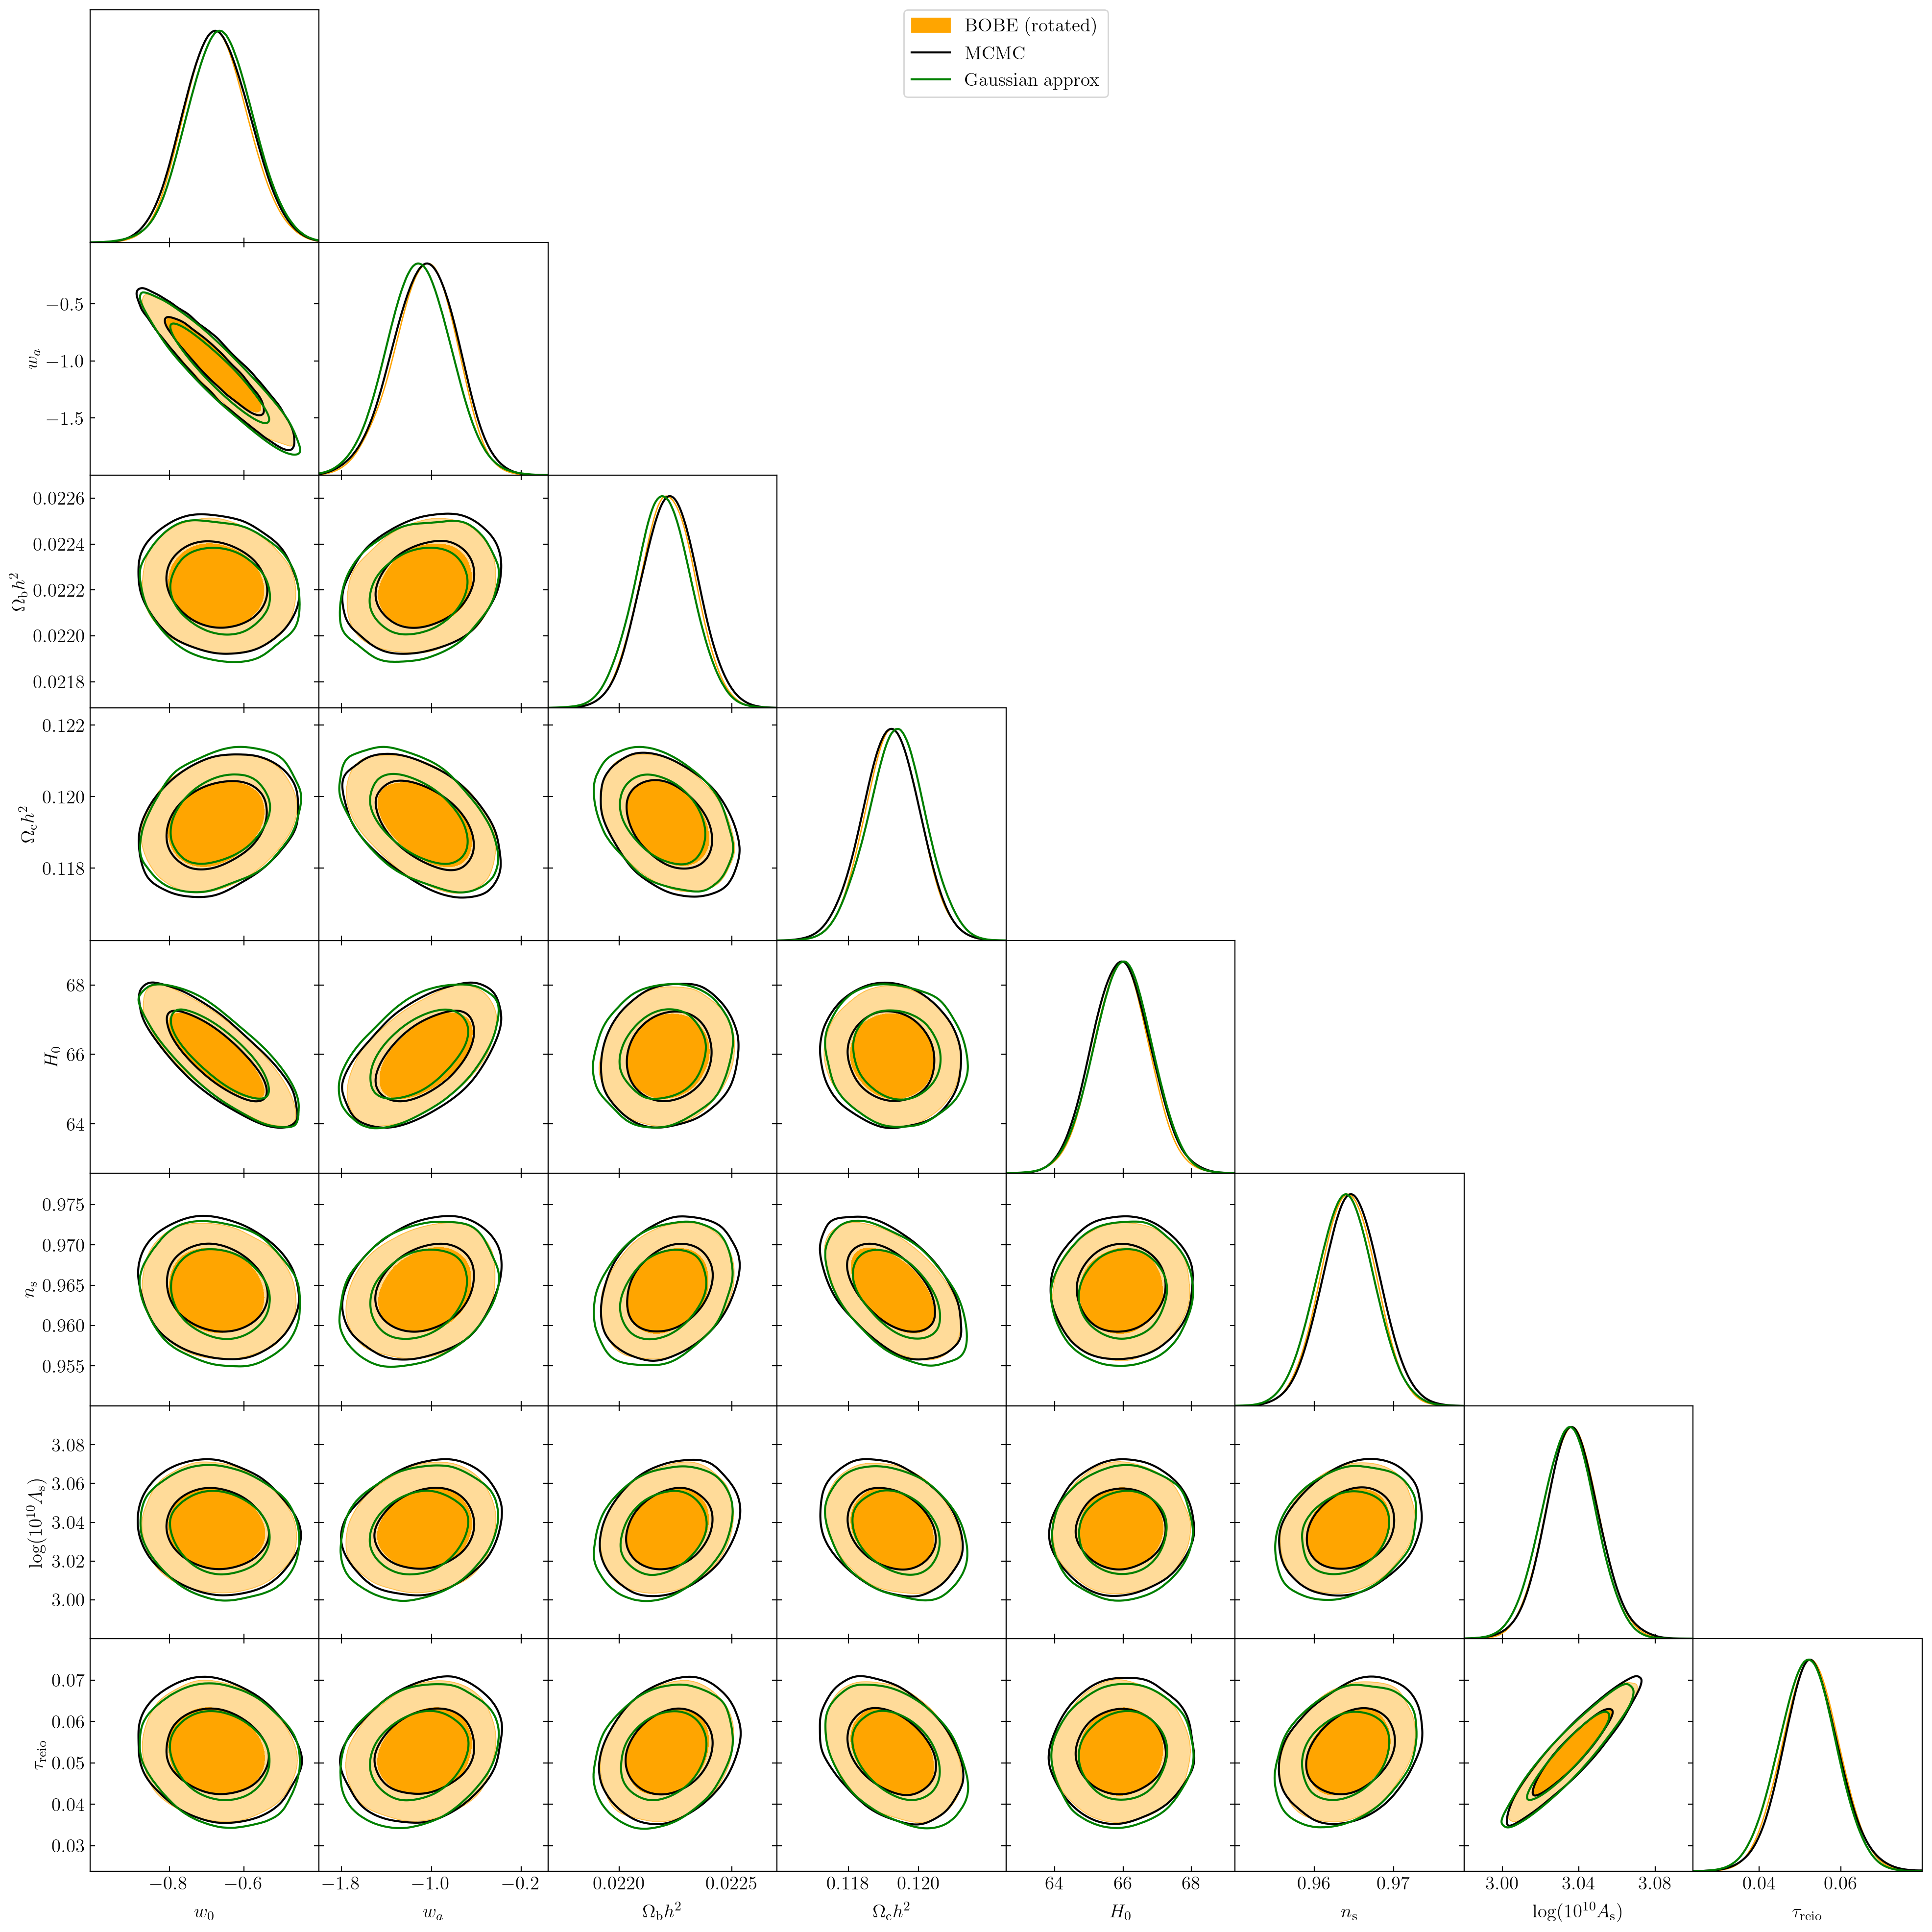

In [5]:
g = plots.get_subplot_plotter(subplot_size=2.5, subplot_size_ratio=1)
g.settings.legend_fontsize = 16
g.settings.axes_fontsize = 16
g.settings.axes_labelsize = 16
g.triangle_plot(
    [bobe_samples, reference_samples, gauss_samples],
            params=['w','wa','ombh2', 'omch2', 'H0', 'ns', 'logA', 'tau'],
            filled=[True, False, False],
            contour_colors=['orange', 'black', 'green'],  #'#006FED'
            contour_lws=[1, 1.5, 1.5],
            legend_labels=['BOBE (rotated)', 'MCMC', 'Gaussian approx'],) 
# g.export('./results/CPL/Planck_DESI_CPL_Rotation_42.pdf')

In [6]:
g = plots.get_subplot_plotter(subplot_size=2.5, subplot_size_ratio=1)
g.settings.legend_fontsize = 16
g.settings.axes_fontsize = 16
g.settings.axes_labelsize = 16
g.triangle_plot(
    [bobe_samples, reference_samples],
            params=param_names,
            filled=[True, False, False],
            contour_colors=['orange', 'black', 'green'],  #'#006FED'
            contour_lws=[1, 1.5, 1.5],
            legend_labels=['BOBE (rotated)', 'MCMC', 'Gaussian approx'],) 
# g.export('./results/CPL/Planck_DESI_CPL_Rotation_42.pdf')